# Метод стрельбы: решение обратной баллистической задачи #

Демонстрация метода стрельбы для решения обратной баллистической задачи.
Находим угол стрельбы для попадания в цель на земле ($y_{target}=0$).


## Импорты ##

In [32]:
import numpy as np
from lesson4_utils import plot_trajectories, plot_convergence

## Параметры системы ##

In [33]:
# Ускорение свободного падения, м/с²
g = 9.81

# Коэффициент сопротивления воздуха, 1/с
k = 0.01

# Скорость горизонтального ветра, м/с
wind_x = 2.0

# Начальная скорость снаряда, м/с
v0 = 50.0

# Целевая точка (x_target, y_target), м
x_target = 200.0
y_target = 0.0

# Начальная точка (x_start, y_start), м
x_start = 0.0
y_start = 0.0

# Точность решения
tolerance = 1e-6

# Максимальное время полета для поиска, с
t_max = 200.0

# Число шагов интегрирования
n_steps = 1000

# Шаг по времени
dt = t_max / n_steps

## 1. Система уравнений движения ##

In [34]:
def equations_of_motion(state):
    """
    Вычисление правых частей системы дифференциальных уравнений движения снаряда.

    Модель учитывает:
    - Гравитационное ускорение (направлено вниз)
    - Сопротивление воздуха (пропорционально скорости)
    - Горизонтальный ветер

    Args:
        state (numpy.ndarray): вектор состояния [t, x, y, vx, vy], где
                               t — время (с), x, y — координаты (м), vx, vy — скорости (м/с)

    Returns:
        numpy.ndarray: вектор производных [1, dx/dt, dy/dt, dvx/dt, dvy/dt]
                       dx/dt, dy/dt - скорости (м/с)
                       dvx/dt, dvy/dt - ускорения (м/с²)
    """
    t, x, y, vx, vy = state

    # Производные координат (скорости)
    dx_dt = vx  # скорость по x
    dy_dt = vy  # скорость по y

    # Производные скоростей (ускорения)
    # Горизонтальное ускорение: сопротивление воздуха + ветер
    dvx_dt = -k * (vx - wind_x)
    # Вертикальное ускорение: гравитация + сопротивление воздуха
    dvy_dt = -g - k * vy

    return np.array([1, dx_dt, dy_dt, dvx_dt, dvy_dt])

In [35]:
def rk4_step(state):
    """
    Один шаг метода Рунге-Кутты 4-го порядка

    Args:
        state (numpy.ndarray): текущее состояние системы [t, x, y, vx, vy]

    Returns:
        numpy.ndarray: состояние системы на следующем шаге [t, x, y, vx, vy]
    """
    k1 = dt * equations_of_motion(state)
    k2 = dt * equations_of_motion(state + 0.5 * k1)
    k3 = dt * equations_of_motion(state + 0.5 * k2)
    k4 = dt * equations_of_motion(state + k3)

    return state + (k1 + 2*k2 + 2*k3 + k4) / 6

## 2. Функции интегрирования траектории ##

In [36]:
def initialize_state(theta):
    """
    Инициализация вектора состояния снаряда для заданного угла стрельбы.

    Args:
        theta (float): начальный угол стрельбы, радианы

    Returns:
        numpy.ndarray: вектор состояния [t, x, y, vx, vy] в начальный момент времени
    """
    vx0 = v0 * np.cos(theta)
    vy0 = v0 * np.sin(theta)
    return np.array([0, x_start, y_start, vx0, vy0])

In [37]:
def integrate_until_ground(initial_state):
    """
    Интегрирование до первого шага ниже земли (y < 0).

    Args:
        initial_state (numpy.ndarray): начальное состояние [t, x, y, vx, vy]

    Returns:
        tuple: (финальное состояние, список состояний траектории)
               Каждое состояние имеет вид [t, x, y, vx, vy].

    Raises:
        ValueError: если падение не произошло до ограничения времени t_max.
    """
    state = initial_state.copy()
    trajectory = [state.copy()]

    # Время хранится в state[0], высота — в state[2].
    while state[0] < t_max and state[2] >= 0:
        state = rk4_step(state)
        trajectory.append(state.copy())

    if state[2] >= 0:
        raise ValueError("Падение не найдено: увеличьте t_max")

    return state, trajectory

In [38]:
def interpolate_ground_impact(trajectory):
    """
    Линейная интерполяция траектории для уточнения точки падения (y = 0).

    Args:
        trajectory (list[numpy.ndarray]): список состояний траектории

    Returns:
        numpy.ndarray: точка падения [t, x, y, vx, vy] при y = 0
    """
    if len(trajectory) < 2:
        return trajectory[-1]

    # Находим последние две точки траектории
    state_prev = trajectory[-2]
    state_curr = trajectory[-1]

    # Линейная интерполяция для уточнения x при y = 0
    if state_curr[2] < 0 and state_prev[2] >= 0:
        # Пропорция времени, когда y пересекает 0
        ratio = -state_prev[2] / (state_curr[2] - state_prev[2])

        # Интерполируем все компоненты состояния
        interpolated_state = state_prev + ratio * (state_curr - state_prev)
        interpolated_state[2] = 0.0  # Точно устанавливаем y = 0
        return interpolated_state

    return state_curr

In [39]:
def integrate_trajectory(theta, return_full_trajectory=False):
    """
    Интегрирование полной траектории снаряда для заданного угла стрельбы.

    Функция моделирует полет снаряда от начальной точки до падения на землю,
    учитывая гравитацию, сопротивление воздуха и горизонтальный ветер.

    Args:
        theta (float): начальный угол стрельбы относительно горизонта, радианы
        return_full_trajectory (bool): если True, возвращает пару (финальное состояние, траектория)

    Returns:
        tuple или numpy.ndarray:
            - Если return_full_trajectory=False: уточнённое состояние [t, x, y, vx, vy] при падении
            - Если return_full_trajectory=True: (финальное состояние, траектория)
              где траектория - numpy.ndarray формы (n_points, 5) с состояниями [t, x, y, vx, vy]
    """
    # Инициализация начального состояния
    initial_state = initialize_state(theta)

    # Интегрирование до падения на землю
    final_state, trajectory = integrate_until_ground(initial_state)

    # Одна и та же уточнённая точка используется в невязке и на графике.
    interpolated_final = interpolate_ground_impact(trajectory)
    trajectory_array = np.array(trajectory)
    trajectory_array[-1] = interpolated_final

    if return_full_trajectory:
        return interpolated_final, trajectory_array
    else:
        return interpolated_final

## 3. Метод стрельбы ##

In [40]:
def residual_function(theta):
    """
    Вычисление функции невязки для метода стрельбы.

    Невязка показывает отклонение точки падения снаряда от целевой координаты x.

    Args:
        theta (float): начальный угол стрельбы, радианы

    Returns:
        float: невязка (x_final - x_target), метры
               положительная - перелет, отрицательная - недолет
    """
    final_state = integrate_trajectory(theta)
    x_final = final_state[1]

    return x_final - x_target

In [53]:
for theta_grad in range(0, 90, 10):
    theta = theta_grad/360 * 2*np.pi
    print(theta_grad, residual_function(theta))

0 -200.0
10 -113.99772454369759
20 -39.91807896393121
30 13.604681366302032
40 40.76898497726455
50 39.0161751554935
60 9.057398842030096
70 -45.24296265283337
80 -117.41219263773709


In [54]:
print(25, residual_function(25/360 * 2*np.pi))

25 -10.164619054181514


In [50]:
print(45, residual_function(45))

45 15.979425447238583


In [ ]:
print(45, residual_function(45))

In [44]:
def initialize_shooting_bounds(theta_left, theta_right):
    """
    Инициализация границ поиска для метода стрельбы.

    Args:
        theta_left (float): левая граница угла стрельбы, радианы
        theta_right (float): правая граница угла стрельбы, радианы

    Returns:
        tuple: (residual_left, residual_right, theta_history, residual_history)
               где theta_history и residual_history содержат начальные значения
    """
    residual_left = residual_function(theta_left)
    residual_right = residual_function(theta_right)

    theta_history = [theta_left, theta_right]
    residual_history = [residual_left, residual_right]

    return residual_left, residual_right, theta_history, residual_history

In [45]:
def compute_new_theta_regula_falsi(theta_left, theta_right, residual_left, residual_right):
    """
    Вычисление нового угла методом regula falsi (ложной позиции).

    Args:
        theta_left (float): левая граница угла, радианы
        theta_right (float): правая граница угла, радианы
        residual_left (float): невязка левой границы
        residual_right (float): невязка правой границы

    Returns:
        float: новый угол стрельбы, радианы
    """
    return (residual_right * theta_left - residual_left * theta_right) / (residual_right - residual_left)

In [46]:
def update_bounds_regula_falsi(theta_left, theta_right, residual_left, residual_right,
                               theta_new, residual_new):
    """
    Обновление границ поиска методом regula falsi.

    Выбирает новую пару точек в зависимости от знаков невязок для обеспечения сходимости.

    Args:
        theta_left (float): текущая левая граница, радианы
        theta_right (float): текущая правая граница, радианы
        residual_left (float): невязка левой границы
        residual_right (float): невязка правой границы
        theta_new (float): новый кандидат угла, радианы
        residual_new (float): невязка нового кандидата

    Returns:
        tuple: (новая_левая_граница, новая_правая_граница,
                новая_невязка_левой, новая_невязка_правой)
    """
    if residual_right * residual_left > 0:
        # Невязки одного знака - выбираем точку ближе к новой
        if abs(theta_new - theta_left) > abs(theta_new - theta_right):
            return theta_new, theta_right, residual_new, residual_right
        else:
            return theta_left, theta_new, residual_left, residual_new
    else:
        # Невязки разных знаков - выбираем точку с противоположным знаком
        if residual_new * residual_left > 0:
            return theta_new, theta_right, residual_new, residual_right
        else:
            return theta_left, theta_new, residual_left, residual_new

In [56]:
def shooting_method(theta_left, theta_right, max_iterations=50):
    """
    Решение обратной баллистической задачи методом стрельбы с использованием regula falsi.

    Метод итеративно уточняет угол стрельбы, чтобы снаряд попадал точно в цель,
    используя пересечение секущей с осью невязки. При разных знаках
    невязки на концах сохраняется интервал, содержащий корень.

    Args:
        theta_left (float): левая граница поиска угла стрельбы, радианы
        theta_right (float): правая граница поиска угла стрельбы, радианы
        max_iterations (int): максимальное число итераций поиска

    Returns:
        tuple: (theta_solution, theta_history, residual_history)
               theta_solution (float): найденный угол стрельбы, радианы
               theta_history (list[float]): история углов на всех итерациях
               residual_history (list[float]): история невязок на всех итерациях

    Raises:
        ValueError: если метод не сошелся за заданное число итераций
    """
    # Инициализация границ и истории
    residual_left, residual_right, theta_history, residual_history = initialize_shooting_bounds(
        theta_left, theta_right)

    print("Начало метода стрельбы:")
    print(f"θ_left = {np.degrees(theta_left):.4f}°, residual_left = {residual_left:.4f} м")
    print(f"θ_right = {np.degrees(theta_right):.4f}°, residual_right = {residual_right:.4f} м")

    # Основной цикл итераций
    for iteration in range(max_iterations):
        # Проверка условий сходимости

        if abs(residual_left) < tolerance or abs(residual_right) < tolerance:
            theta_solution = theta_left if abs(residual_left) < tolerance else theta_right
            print(f"Решение найдено: θ = {np.degrees(theta_solution):.4f}°")
            return theta_solution, theta_history, residual_history

        if abs(residual_right - residual_left) < tolerance:
            raise ValueError("Метод не сошелся: невязки слишком близки")

        # Вычисление нового кандидата угла
        theta_new = compute_new_theta_regula_falsi(theta_left, theta_right, residual_left, residual_right)
        residual_new = residual_function(theta_new)

        # Сохранение в истории
        theta_history.append(theta_new)
        residual_history.append(residual_new)

        print(f"Итерация {iteration+1}: θ = {np.degrees(theta_new):.4f}°, невязка = {residual_new:.4f} м")

        if abs(residual_new) < tolerance:
            print(f"Решение найдено: θ = {np.degrees(theta_new):.4f}°")
            return theta_new, theta_history, residual_history

        # Обновление границ поиска
        theta_left, theta_right, residual_left, residual_right = update_bounds_regula_falsi(
            theta_left, theta_right, residual_left, residual_right, theta_new, residual_new)

    raise ValueError(f"Метод не сошелся за {max_iterations} итераций")

## 4. Демонстрация метода стрельбы ##

МЕТОД СТРЕЛЬБЫ: ОБРАТНАЯ БАЛЛИСТИЧЕСКАЯ ЗАДАЧА
Целевая точка: x = 200.0 м, y = 0.0 м
Начальная скорость: v0 = 50.0 м/с
Сопротивление воздуха: k = 0.01 1/с
Горизонтальный ветер: wx = 2.0 м/с

Начало метода стрельбы:
θ_left = 10.0000°, residual_left = -113.9977 м
θ_right = 45.0000°, residual_right = 43.5421 м
Итерация 1: θ = 35.3264°, невязка = 31.6111 м
Итерация 2: θ = 29.8281°, невязка = 12.9207 м
Итерация 3: θ = 27.8096°, невязка = 3.9652 м
Итерация 4: θ = 27.2109°, невязка = 1.1694 м
Итерация 5: θ = 27.0362°, невязка = 0.3590 м
Итерация 6: θ = 26.9827°, невязка = 0.0829 м
Итерация 7: θ = 26.9704°, невязка = 0.0193 м
Итерация 8: θ = 26.9675°, невязка = 0.0045 м
Итерация 9: θ = 26.9668°, невязка = 0.0010 м
Итерация 10: θ = 26.9667°, невязка = 0.0002 м
Итерация 11: θ = 26.9666°, невязка = 0.0001 м
Итерация 12: θ = 26.9666°, невязка = 0.0000 м
Итерация 13: θ = 26.9666°, невязка = 0.0000 м
Итерация 14: θ = 26.9666°, невязка = 0.0000 м
Решение найдено: θ = 26.9666°

Результат метода стрель

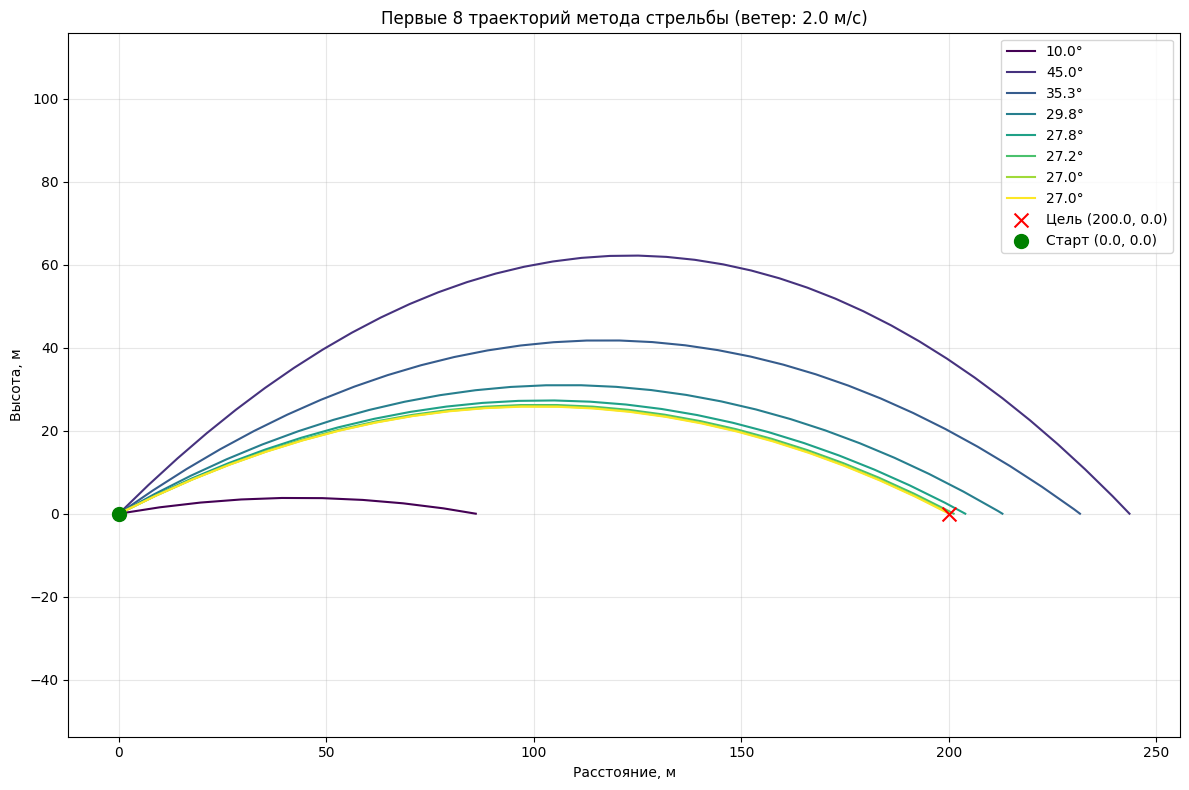

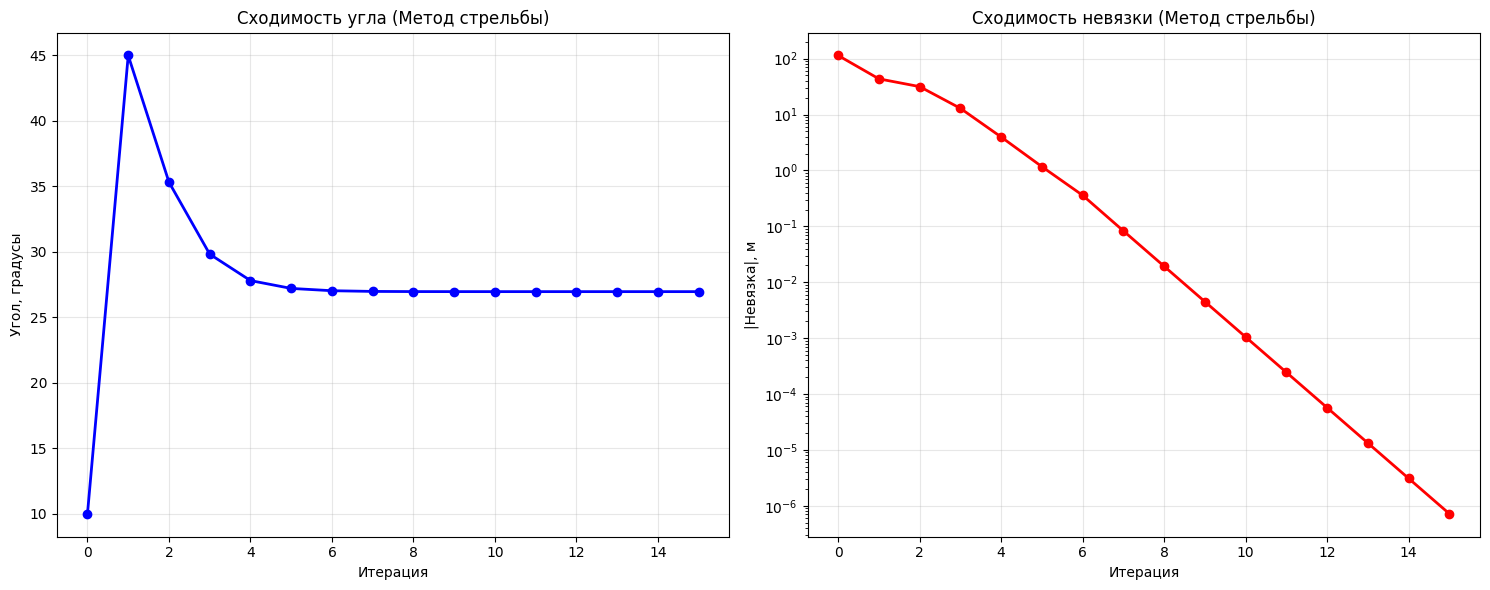

In [57]:
# Настройка границ поиска
theta_left = np.radians(10)   # 10 градусов - снаряд не долетит
theta_right = np.radians(45)  # 45 градусов - снаряд перелетит

# Вывод заголовка и параметров задачи
print("="*60)
print("МЕТОД СТРЕЛЬБЫ: ОБРАТНАЯ БАЛЛИСТИЧЕСКАЯ ЗАДАЧА")
print("="*60)
print(f"Целевая точка: x = {x_target} м, y = {y_target} м")
print(f"Начальная скорость: v0 = {v0} м/с")
print(f"Сопротивление воздуха: k = {k} 1/с")
print(f"Горизонтальный ветер: wx = {wind_x} м/с")
print()

# Запуск метода стрельбы
theta_shooting, theta_hist_shooting, residual_hist_shooting = shooting_method(theta_left, theta_right)

# Вывод результатов
print("\nРезультат метода стрельбы:")
print(f"Угол стрельбы: {np.degrees(theta_shooting):.6f}°")
print(f"Невязка: {residual_function(theta_shooting):.2e}")

# Проверка решения
final_state = integrate_trajectory(theta_shooting)
print(f"Достигнутая точка: x = {final_state[1]:.3f} м, y = {final_state[2]:.3f} м")

# Визуализация первых траекторий
print("\nВизуализация первых траекторий метода стрельбы...")
n_trajectories = min(8, len(theta_hist_shooting))
plot_trajectories(theta_hist_shooting[:n_trajectories], integrate_trajectory,
                 x_target, y_target, x_start, y_start,
                 f"Первые {n_trajectories} траекторий метода стрельбы (ветер: {wind_x} м/с)",
                 coordinate_indices=(1, 2))

# Визуализация процесса сходимости
plot_convergence(theta_hist_shooting, residual_hist_shooting, "Метод стрельбы")

## Выводы ##

## Результаты решения обратной баллистической задачи методом стрельбы

Метод стрельбы успешно решил обратную баллистическую задачу, найдя угол стрельбы,
при котором численная невязка меньше заданного допуска, с учетом сопротивления воздуха и ветра.

### Ключевые особенности решения:

1. **Начальные границы**: Выбраны углы 10° (недолёт) и 45° (перелёт).
   Невязки имеют разные знаки; regula falsi сохраняет интервал с корнем.
   При 80° снаряд также не долетает, поэтому пара 10° и 80° не даёт такой гарантии.

2. **Процесс сходимости**: Метод показал постепенное приближение к правильному углу
   через последовательные "выстрелы" с корректировкой угла

3. **Визуализация**: Графики показывают, как каждая итерация приближает траекторию
   к целевой точке, демонстрируя принцип "пристрелки"

4. **Точность**: Критерий остановки — модуль численной невязки меньше `tolerance = 1e-6` м.
   Это точность поиска корня численной модели. Погрешности интегрирования и линейного
   уточнения момента падения нужно оценивать отдельно, уменьшая шаг `dt`.